<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-exam-scores-analysis-eda-ml-85-37?scriptVersionId=269558135" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-exam-scores-analysis-ipyn/student_exam_scores.csv


## Student Exam Scores Analysis

## Description:

This notebook analyzes student exam performance to uncover insights about learning outcomes and influencing factors. It explores patterns in exam scores across subjects, identifies correlations between study habits and performance, and applies machine learning models to predict student success. Visualizations and statistical summaries are included to highlight key trends, helping educators and analysts understand academic strengths, weaknesses, and areas for improvement.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/student-exam-scores-analysis-ipyn/student_exam_scores.csv")

In [3]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [4]:
df.tail()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0
199,S200,10.2,6.3,97.4,68,37.8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [6]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [7]:
df.nunique()

student_id            200
hours_studied          96
sleep_hours            50
attendance_percent    167
previous_scores        54
exam_score            139
dtype: int64

In [8]:
df.isnull().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.describe().loc[['mean','max','min']]

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
mean,6.3255,6.622,74.83,66.8,33.955
max,12.0000,9.000,100.00,95.0,51.300
min,1.0000,4.000,50.30,40.0,17.100


In [11]:
df.dtypes

student_id             object
hours_studied         float64
sleep_hours           float64
attendance_percent    float64
previous_scores         int64
exam_score            float64
dtype: object

In [12]:
df.shape

(200, 6)

In [13]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

## Data visualizations

In [14]:
from scipy.stats import linregress

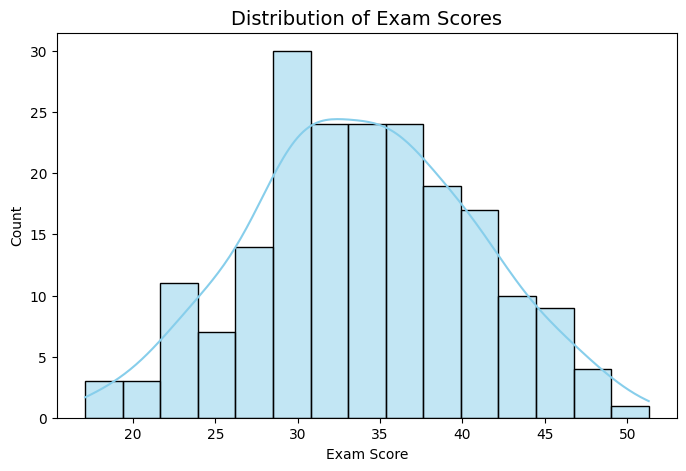

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Exam Scores', fontsize=14)
plt.xlabel('Exam Score')
plt.ylabel('Count')
plt.show()

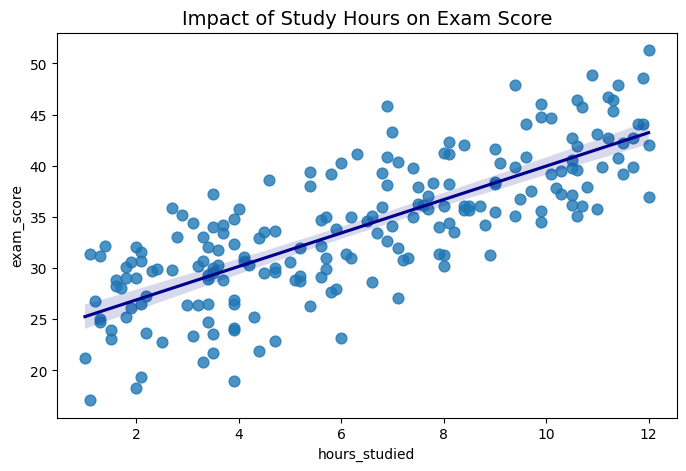

In [16]:
plt.figure(figsize=(8, 5))
sns.regplot(x='hours_studied', y='exam_score', data=df, scatter_kws={'s':60}, line_kws={'color':'darkblue'})
plt.title('Impact of Study Hours on Exam Score', fontsize=14)
plt.show()

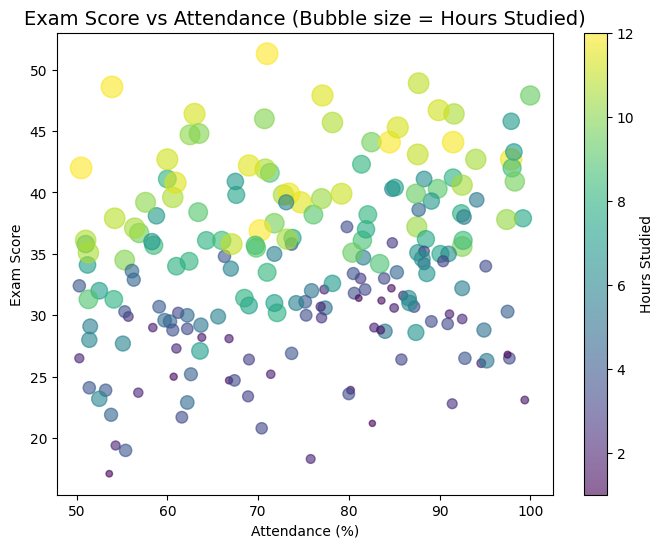

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(df['attendance_percent'], df['exam_score'], 
            s=df['hours_studied']*20, alpha=0.6, c=df['hours_studied'], cmap='viridis')
plt.title('Exam Score vs Attendance (Bubble size = Hours Studied)', fontsize=14)
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.colorbar(label='Hours Studied')
plt.show()

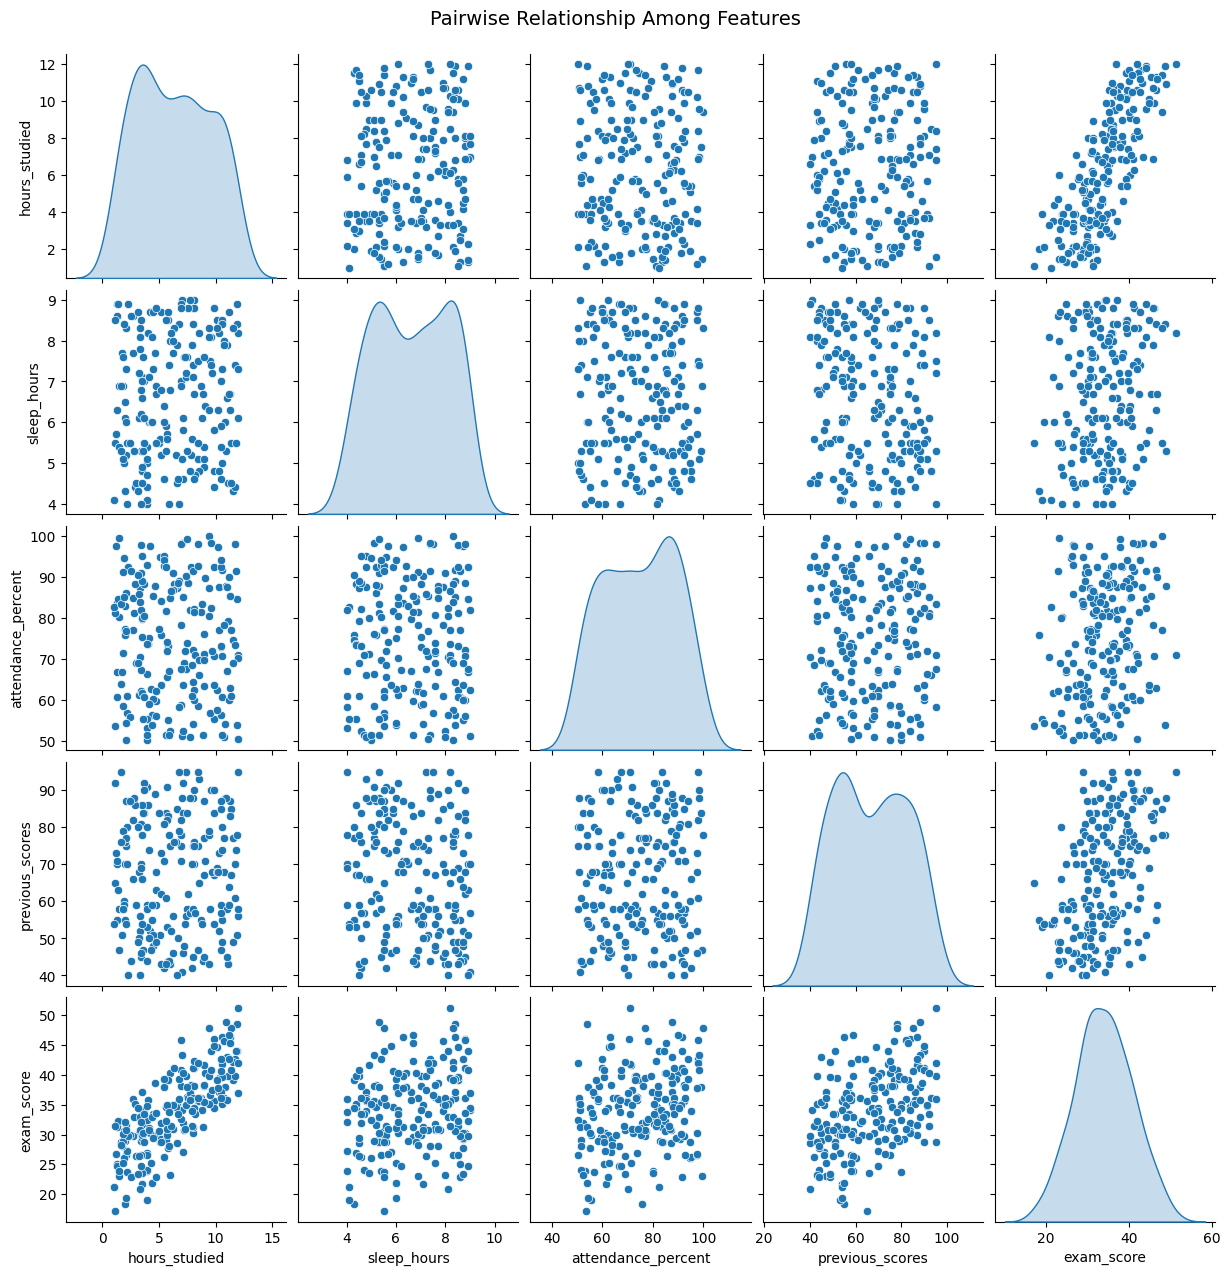

In [18]:
sns.pairplot(df[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']], 
             diag_kind='kde', palette='coolwarm')
plt.suptitle('Pairwise Relationship Among Features', y=1.02, fontsize=14)
plt.show()

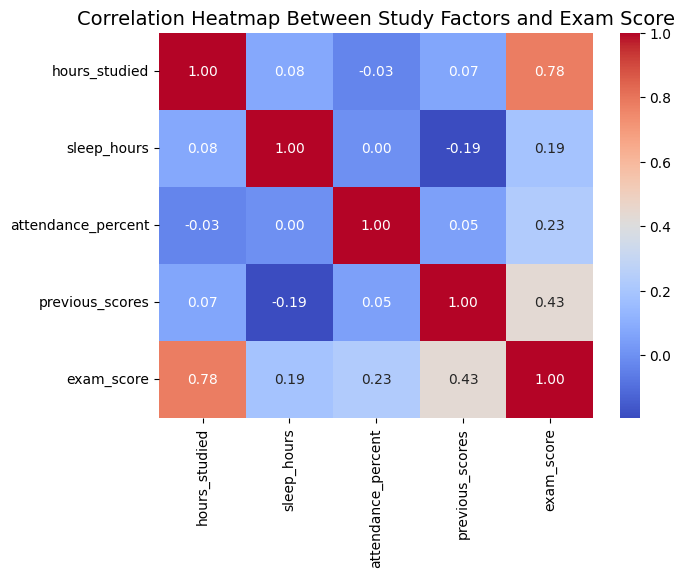

In [19]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap Between Study Factors and Exam Score', fontsize=14)
plt.show()

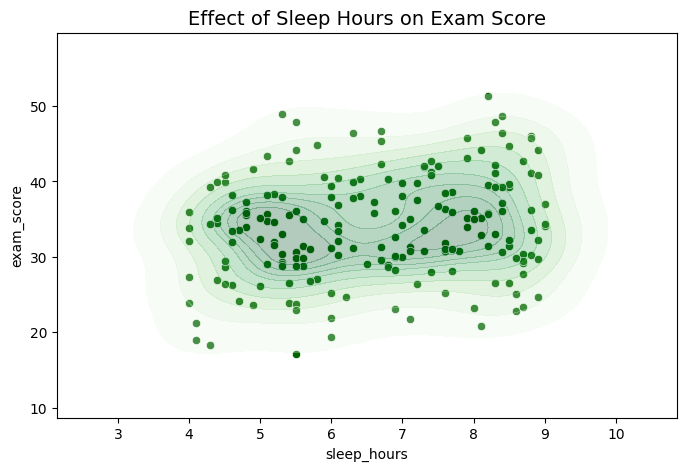

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='sleep_hours', y='exam_score', data=df, color='darkgreen')
sns.kdeplot(x='sleep_hours', y='exam_score', data=df, cmap='Greens', fill=True, alpha=0.3)
plt.title('Effect of Sleep Hours on Exam Score', fontsize=14)
plt.show()

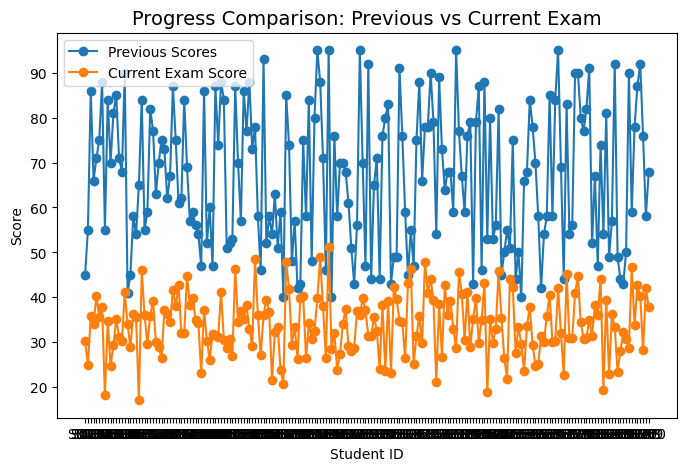

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(df['student_id'], df['previous_scores'], label='Previous Scores', marker='o')
plt.plot(df['student_id'], df['exam_score'], label='Current Exam Score', marker='o')
plt.title('Progress Comparison: Previous vs Current Exam', fontsize=14)
plt.xlabel('Student ID')
plt.ylabel('Score')
plt.legend()
plt.show()

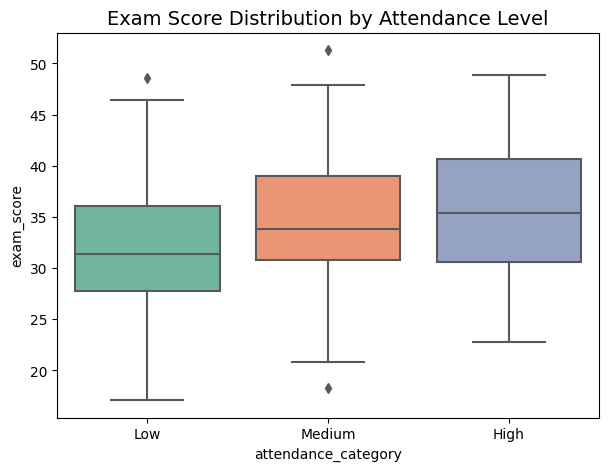

In [22]:
df['attendance_category'] = pd.cut(df['attendance_percent'], bins=[0,70,85,100], 
                                   labels=['Low','Medium','High'])
plt.figure(figsize=(7,5))
sns.boxplot(x='attendance_category', y='exam_score', data=df, palette='Set2')
plt.title('Exam Score Distribution by Attendance Level', fontsize=14)
plt.show()

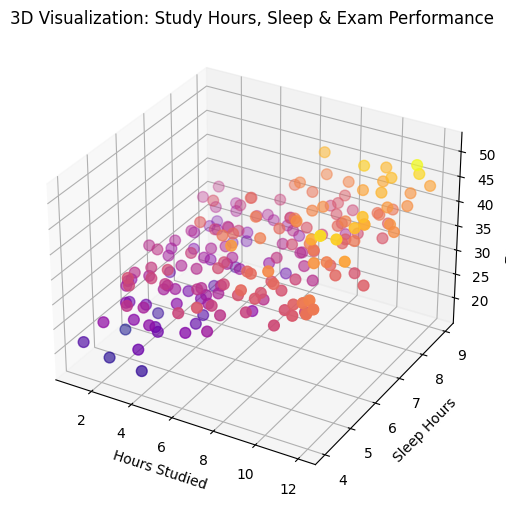

In [23]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['hours_studied'], df['sleep_hours'], df['exam_score'], c=df['exam_score'], cmap='plasma', s=60)
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Sleep Hours')
ax.set_zlabel('Exam Score')
ax.set_title('3D Visualization: Study Hours, Sleep & Exam Performance')
plt.show()

## ML algorithms

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [26]:
print(df.columns.tolist())

['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score', 'attendance_category']


In [27]:
le = LabelEncoder()
df['attendance_category'] = le.fit_transform(df['attendance_category']) 

In [28]:
X = df.drop(['student_id', 'exam_score'], axis=1)
y = df['exam_score']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

In [32]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred) * 100  # convert to %
    results[name] = r2

In [33]:
print("Model Performance (R² Score %):\n")
for name, score in results.items():
    print(f"{name}: {score:.2f}%")

Model Performance (R² Score %):

Linear Regression: 85.37%
Ridge Regression: 85.37%
Lasso Regression: 74.88%
Decision Tree: 56.75%
Random Forest: 78.65%
Gradient Boosting: 77.48%
AdaBoost: 80.16%
Support Vector Regressor: 67.68%
KNN Regressor: 72.70%


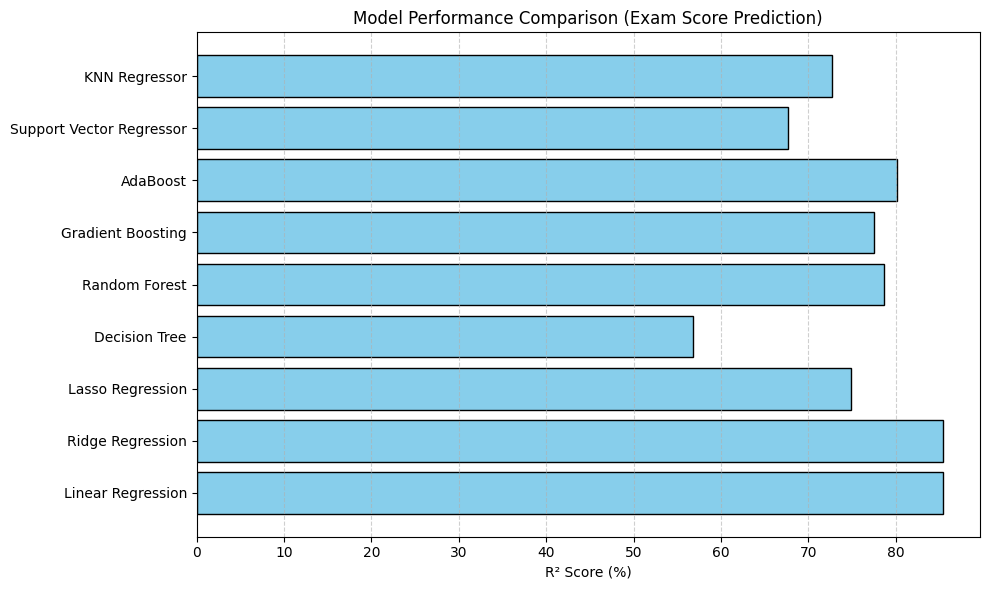

In [34]:
plt.figure(figsize=(10, 6))
plt.barh(list(results.keys()), list(results.values()), color='skyblue', edgecolor='black')
plt.xlabel('R² Score (%)')
plt.title('Model Performance Comparison (Exam Score Prediction)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## THank you...pls upvote!!!!